In [6]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
import pandas as pd
import glob, os
import warnings
import platform

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 700)


if platform.system() == "Darwin":  # macOS
    path = r'/Users/admin/Desktop/중요한것/Study-ML-DL-AI/allData/OpinosisDataset1.0/topics'
elif platform.system() == "Windows":  # Windows
    path = r'C:\Users\USER\OneDrive\바탕 화면\과제 정리\공부용\Study-ML-DL-AI\allData\OpinosisDataset1.0\topics'

all_files = glob.glob(os.path.join(path, "*.data"))
filename_list = []
opinion_text = []

for file_ in all_files:
    df = pd.read_table(
        file_,
        header=None,
        encoding='latin1'
    )

    filename = os.path.basename(file_).split('.')[0]

    filename_list.append(filename)

    # 각 행의 문장만 공백으로 이어 붙임
    opinion_text.append(
        ' '.join(df[0].astype(str).tolist())
    )

document_df = pd.DataFrame({
    'filename': filename_list,
    'opinion_text': opinion_text
})

document_df.head(3)

,filename,opinion_text
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate . but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go . This function is not accurate if you don't leave it in battery mode say, when you stop at the Cracker Barrell for lunch and to play one of those trangle games with the tees . It provides immediate alternatives if the route from the online map program was inaccurate or blocked by an obstacle . I've used other GPS units, as well as GPS built into cars and to this day NOTHING beats the accuracy of a Garmin GPS . It got me from point A to point B with 100% accuracy everytime . It has yet to disappoint, getting me everywhere with 100% accurac..."
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms . The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep . Large comfortable room, wonderful bathroom . The rooms were nice, very comfy bed and very clean bathroom . Bathroom was spacious too and very clean . The bathroom only had a single sink, but it was very large . The room was a standard but nice motel room like any other, bathroom seemed upgraded if I remember . The room was quite small but perfectly formed with a super bathroom . You could eat off the bathroom floor it was so clean . The bathroom do..."
2,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever ! After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there ! NO USER REPLACEABLE BATTERY, , Unless you buy the extended warranty for $65 . After 1 year you pay $80 plus shipping to send the device to Amazon and have the Kindle REPLACED, not the battery changed out . The fact that Kindle 2 has no SD card capability and the battery is not user, serviceable is not an issue with me . Things like the buttons that made it easy to accidentally turn pag..."


In [12]:
import nltk
import string

from nltk.stem import WordNetLemmatizer

lemmer = WordNetLemmatizer()

def LemTokens(tokens):
    return [lemmer.lemmatize(token) for token in tokens]

remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)

def LemNormalize(text):
    return LemTokens(
        nltk.word_tokenize(
            text.lower().translate(remove_punct_dict)
        )
    )

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english' , \
                             ngram_range=(1,2), min_df=0.05, max_df=0.85)

feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

In [14]:
from sklearn.cluster import KMeans

km_cluster = KMeans(n_clusters=5, max_iter=1000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
cluster_cluster = km_cluster.cluster_centers_

In [15]:
document_df['cluster_label'] = cluster_label
document_df.head()

,filename,opinion_text,cluster_label
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate . but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go . This function is not accurate if you don't leave it in battery mode say, when you stop at the Cracker Barrell for lunch and to play one of those trangle games with the tees . It provides immediate alternatives if the route from the online map program was inaccurate or blocked by an obstacle . I've used other GPS units, as well as GPS built into cars and to this day NOTHING beats the accuracy of a Garmin GPS . It got me from point A to point B with 100% accuracy everytime . It has yet to disappoint, getting me everywhere with 100% accurac...",2
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms . The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep . Large comfortable room, wonderful bathroom . The rooms were nice, very comfy bed and very clean bathroom . Bathroom was spacious too and very clean . The bathroom only had a single sink, but it was very large . The room was a standard but nice motel room like any other, bathroom seemed upgraded if I remember . The room was quite small but perfectly formed with a super bathroom . You could eat off the bathroom floor it was so clean . The bathroom do...",1
2,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever ! After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there ! NO USER REPLACEABLE BATTERY, , Unless you buy the extended warranty for $65 . After 1 year you pay $80 plus shipping to send the device to Amazon and have the Kindle REPLACED, not the battery changed out . The fact that Kindle 2 has no SD card capability and the battery is not user, serviceable is not an issue with me . Things like the buttons that made it easy to accidentally turn pag...",4
3,battery-life_ipod_nano_8gb,"short battery life I moved up from an 8gb . I love this ipod except for the battery life . long battery scratch resistant Battery drains even if I don't use it . I only wonder why the battery seems to drain when I'm not using it, even after sliding the top control button to off when shutting down . great in the car, light, portable, good quality, long battery,scratch resistant . 5G lies a more mature iPod, many steps wiser and more able than its one, year, old The iPod gains many incremental improvements, including a brighter screen and better video battery life, but probably the most appealing aspect is the tantalizing price points of $249 for the 30GB version and $349 for the h...",4
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 . Not to mention that as of now Asus will not sell you a spare 3 or 6, cell Li, Ion battery . It also features a N270 cpu, 6, cell 48Wh Li, ion Battery 8 . 3MP webcam, 6, Cell 63Wh Li, ion Battery with a whopping 10 . Realistic battery numbers are between 8 . of battery life if you're using wifi & doing email word processing YouTube web surfing . The Eee Super Hybrid Engine utility lets users overclock or underclock their Eee PC's to boost performance or provide better battery life depending on their immediate requirements . A few other things I'd like to point out is that you must push the micro, sized right ...",4


In [16]:
document_df[document_df['cluster_label']==0].sort_values(by='filename')

,filename,opinion_text,cluster_label
5,buttons_amazon_kindle,"I thought it would be fitting to christen my Kindle with the Stephen King novella UR, so went to the Amazon site on my computer and clicked on the button to buy it . As soon as I'd clicked the button to confirm my order it appeared on my Kindle almost immediately ! After reading through the introductory guide that loads up automatically at the start and following along it took me almost no time to learn which buttons are where and what each of them do . I started reading with the default size without my glasses and noticed I was squinting a bit, so changed to one size larger with a couple button clicks and it was much easier without feeling like the print was too big and took up too mu...",0
10,eyesight-issues_amazon_kindle,"It feels as easy to read as the K1 but doesn't seem any crisper to my eyes . the white is really GREY, and to avoid considerable eye, strain I had to refresh pages every other page . The dream has always been a portable electronic device that could hold a ton of reading material, automate subscriptions and facilitate quick easy downloads, and be as portable, as easy on the eyes, and as intuitive as a book . they would ask, to which I would squint my eyes and reply, Huh ? I found that the Kindle 2 is immediately appealing to the eye and once described in the barest of terms people want one for themselves . No having to turn away every few minutes to relax your eyes or ending ...",0
12,fonts_amazon_kindle,"Being able to change the font sizes is awesome ! For whatever reason, Amazon decided to make the Font on the Home Screen than on the K1 . I found myself constantly changing the angle of the body, changing the font size up and down and the distance away from me . I was an avid reader but increasing age has made printed books more of a challenge, but the Kindle with its varying font size and very light weight has made reading fun again . What's more, it's easy to change font size . The kindle does not recognize page numbers, since they would change radically when you change font size so Amazon provides the notion of location which is display independent . I just crank the font up ...",0
23,navigation_amazon_kindle,"In fact, the entire navigation structure has been completely revised , I'm still getting used to it but it's a huge step forward . Navigation is a huge improvement . Clearly, Amazon was hard at work to make navigation quicker and easier . I tried out the free 14 day trial on newspaper downloads, what a great way to get your news, no advertising distractions, easy to navigate and automatically downloaded every day . Once I got used to it, the navigation was easy too . The Sony store is cumbersome to navigate, and slow . Despite the lighter text, I prefer the K2 for its thinness and its improved navigation and I use if far more than my K1 . On the Kindle, you have wireless delivery...",0
27,price_amazon_kindle,"If a case was included, as with the Kindle 1, that would have been reflected in a higher price . lower overall price, with nice leather cover . If you have the first Kindle and are deciding whether to upgrade, do it now while you can still get a good price for your old Kindle on Amazon's Marketplace, craigslist, wherever . Before purchasing, I was obsessed with the reviews and predictions I found online and reading about some of the critiques such as the thick border, the lack of touchscreen, lack of battery SD slot, lack of a back light, awkward difficult keyboard layout, minimally faster page flipping, and the super, high price . However, I think all the positives of the K2 greatly...",0
28,price_holiday_inn_london,"All in all, a normal chain hotel on a nice location , I will be back if I do not find anthing closer to Picadilly for a better price . Great Price Terrific Location . Our main focus before booking was looking for a low price with good location . All for the bargain price off £ 250 for 2 nights including return rail to

In [17]:
document_df[document_df['cluster_label']==1].sort_values(by='filename')

,filename,opinion_text,cluster_label
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms . The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep . Large comfortable room, wonderful bathroom . The rooms were nice, very comfy bed and very clean bathroom . Bathroom was spacious too and very clean . The bathroom only had a single sink, but it was very large . The room was a standard but nice motel room like any other, bathroom seemed upgraded if I remember . The room was quite small but perfectly formed with a super bathroom . You could eat off the bathroom floor it was so clean . The bathroom do...",1
13,food_holiday_inn_london,"The room was packed to capacity with queues at the food buffets . The over zealous staff cleared our unfinished drinks while we were collecting cooked food and movement around the room with plates was difficult in the crowded circumstances . There are a couple pubs, a great patisserie and even fast food restaurants within a block . The neighborhood is an upscale residential area full of restaurants in easy walking distance ranging from fast food to up, scale with a wide variety of cuisines , , we never had a bad meal . The food was wonderful, a selection of sandwiches, salads, cous cous and spicy wedge potato's, fruit salad and a cake was a good fill up when needed . Full Engli...",1
14,food_swissotel_chicago,"The food for our event was delicious . The food in the lounge was great and very fresh, , , salads, sandwiches etc . As far as food, walk a few blocks toward Michigan Ave turn left or right and there are plently of less expensive places to eat . The Palm resturant in the hotel had some specials Sunday night, we ate there and the food service,etc were outstanding portions are large and we shared since we are not big eaters . Took the charge of the minibar which we had used to keep my 2 year old sons food . We never ate anything onsite so I can't vouch for the food options immediately avialable . The Lobby bar does not serve food very late at night and we couldn't find any vending m...",1
15,free_bestwestern_hotel_sfo,"The wine reception is a great idea as it is nice to meet other travellers and great having access to the free Internet access in our room . They also have a computer available with free internet which is a nice bonus but I didn't find that out till the day before we left but was still able to get on there to check our flight to Vegas the next day . The service was good, very friendly staff and we loved the free wine reception each night . has free wireless and help you with transportation needs . The nightly free wine tasting from 5 , 6 pm is a brilliant idea and gets guests together to socialise witheach other . They have a happy hour where you have a couple offree drinks between ...",1
20,location_bestwestern_hotel_sfo,"Good Value good location , ideal choice . Great Location , Nice Rooms , Helpless Concierge The location is good, and the overall decor is nice, but there was nothing that I can really rave about . Overall, it was a good location, but an average hotel with serious noise issues . A perfect hotel a perfect location perfect staff ! The location is perfect to pier 39 and surrounding areas . My husband found this hotel on Trip Advisor and it ranked very high and we weren't disappointed at all as it is in a great location and a very nice hotel . The hotel location was perfect . My husband and I stayed for two nights at the Tuscan Inn and enjoyed it's great location to Fisherman Wharf a...",1
21,location_holiday_inn_london,"Great location for tube and we crammed in a fair amount of sightseeing in a short time . All in all, a normal chain hotel on a nice location , I will be back if I do not find anthing closer to Picadilly for a better price . Great Price Terrific Location . The location is absolutely wonderful . Our mai

In [18]:
document_df[document_df['cluster_label']==2].sort_values(by='filename')

,filename,opinion_text,cluster_label
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate . but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go . This function is not accurate if you don't leave it in battery mode say, when you stop at the Cracker Barrell for lunch and to play one of those trangle games with the tees . It provides immediate alternatives if the route from the online map program was inaccurate or blocked by an obstacle . I've used other GPS units, as well as GPS built into cars and to this day NOTHING beats the accuracy of a Garmin GPS . It got me from point A to point B with 100% accuracy everytime . It has yet to disappoint, getting me everywhere with 100% accurac...",2
8,directions_garmin_nuvi_255W_gps,"You also get upscale features like spoken directions including street names and programmable POIs . I used to hesitate to go out of my directions but not any more . the directions didn't tell me anything I didn't already know after fiddling with it for 10 minutes . It also does not offer an option to view the route as a series of turn by turn directions . It gives your heading not in terms of degres but only in terms of one of eight directions . The widescreen is a plus and I highly recommend it, even though it has the wide screen you can stick it in your back pocket which can be conveniently used for walking directions . Garmin's nuvi 255W is a handy little device that provides...",2
9,display_garmin_nuvi_255W_gps,"3 quot widescreen display was a bonus . This made for smoother graphics on the 255w of the vehicle moving along displayed roads, where the 750's display was more of a jerky movement . I also found that the display on the 255w was a bit brighter, clearer, and more vivid than on the 750 in both daylight and at night . The 750 just displays text on the top line for upcoming turns without the arrow . The 255 also automatically adjusts the font size of displayed text so that even lengthy text will fit . Another feature on the 255w is a display of the posted speed limit on the road which you are currently on right above your current displayed speed . The 255W has a really clear display ...",2
19,keyboard_netbook_1005ha,", I think the new keyboard rivals the great hp mini keyboards . Since the battery life difference is minimum, the only reason to upgrade would be to get the better keyboard . The keyboard is now as good as the HP and Samsung netbooks . The keyboards are 92% the size of those found on a standard computer and the machines run a little hot . The keyboard is large enough to accommodate touch typing with ease . At home I now have my Asus connected to my desktop's keyboard and monitor . However, since I do a lot of word processing, the keyboard and the touchpad buttons were a real concern . The keyboard has a responsive feel and the larger keys along with the oversize right shift key ...",2
33,satellite_garmin_nuvi_255W_gps,"It's fast to acquire satellites . If you've ever had a Brand X GPS take you on some strange route that adds 20 minutes to your trip, has you turn the wrong way down a one way road, tell you to turn AFTER you've passed the street, frequently loses the satellite signal, or has old maps missing streets, you know how important this stuff is . The Garmin Nuvi 255W connects to satellites extremely fast, , So when I get in my car and turn it on, we're pretty much ready to go immediately . It picks up the satellites quickly , routes fast, has good animation maybe 6, 8 frames a second ? The revised chipset allows the GPS to make satellite connections quickly . The unit takes very quickly ...",2
34,screen_garmin_nuvi_255W_gps,"It is easy to read and when touching the screen it works great ! and zoom out buttons on the 255w to the same side of the screen which makes it a bit easier . On the 750 the zoom buttons are on opposite sides of the screen . The screen is easily readable in the sun, and I love how it automatic

In [19]:
document_df[document_df['cluster_label']==3].sort_values(by='filename')

,filename,opinion_text,cluster_label
6,comfort_honda_accord_2008,"Drivers seat not comfortable, the car itself compared to other models of similar class . It's very comfortable, remarkably large inside and just an overall great vehicle . Front seats are very uncomfortable . I'm 6' tall, and find the driving position pretty comfortable . However, there are a couple of things that kill it for me 1 terrible driver seat comfort, kills my back 2 lack luster interior design, my Acadia has much better comfort 3 the VCM drives me crazy because the constant change in cylinder use is perceptible enough to be an annoyance . The seats are extremely uncomfortable . While the Accord is no Acura it is a close relative in terms of quality and comfort . I previ...",3
7,comfort_toyota_camry_2007,"Ride seems comfortable and gas mileage fairly good averaging 26 city and 30 open road . Seats are fine, in fact of all the smaller sedans this is the most comfortable I found for the price as I am 6', 2 and 250# . Great gas mileage and comfortable on long trips . Good gas mileage, comfortable seating, lots of leg room . Lots of comfort for the price . The ride is loud and not comfortable . I drive 2 hours to work each day and it is just not comfortable to me . Getting about 26 mpg mixed city hwy with conservative driving, seating 4 people comfortably . The ride is quiet and comfortable . Styling is bland, the engine isn't strong at all, and the car doesn't deliver good comfort...",3
16,gas_mileage_toyota_camry_2007,"Ride seems comfortable and gas mileage fairly good averaging 26 city and 30 open road . It gets great gas mileage . Being a mother who drives a lot I wanted a safe vehicle with good gas mileage and this car delivered that and more . Great gas mileage and comfortable on long trips . Nice looking car and good gas mileage . Good gas mileage, comfortable seating, lots of leg room . The interior is roomy, the ride is smooth and solid and yet it has excellent gas mileage . The gas mileage is still good, cant give specifics but for a V6, its good . I had my OEM Turanzas wear out at 14K and was lucky to get local Bridgestones to gimme a mileage warranty adjustment, got new tires for $...",3
17,interior_honda_accord_2008,"I love the new body style and the interior is a simple pleasure except for the center dash . However, there are a couple of things that kill it for me 1 terrible driver seat comfort, kills my back 2 lack luster interior design, my Acadia has much better comfort 3 the VCM drives me crazy because the constant change in cylinder use is perceptible enough to be an annoyance . Love the interior and the power and speed, but not hard to beat after what I had . Love the interior and exterior look, the V6 is sensational, and getting compliments on the steel metallic color as if it's a Lexus or BMW . The seats are decent, the interior design is excellent IMO as well as the exterior design, an...",3
18,interior_toyota_camry_2007,"First of all, the interior has way too many cheap plastic parts like the cheap plastic center piece that houses the clock . 3 blown struts at 30,000 miles, interior trim coming loose and rattling squeaking, stains on paint, and bug splats taking paint off, premature uneven brake wear, on 3rd windshield . Insanely cheap plastic all over interior . Disappointed in interior and exterior quality . I love the color of the exterior and interior . This car is nearly perfect when compared to other cars in this class regarding interior dimensions, visibility, exterior styling, etc . Several parts in the interior rattle including the sunroof and some parts of the dash, the radio randomly...",3
22,mileage_honda_accord_2008,"It's quiet, get good gas mileage and looks clean inside and out . The mileage is great, and I've had to get used to stopping less for gas . Thought gas mileage would be better . There are trade offs that I have no problems with, my mileage after two tanks with mostly city driving is 21 but acceleration is ve

In [20]:
document_df[document_df['cluster_label']==4].sort_values(by='filename')

,filename,opinion_text,cluster_label
2,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever ! After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there ! NO USER REPLACEABLE BATTERY, , Unless you buy the extended warranty for $65 . After 1 year you pay $80 plus shipping to send the device to Amazon and have the Kindle REPLACED, not the battery changed out . The fact that Kindle 2 has no SD card capability and the battery is not user, serviceable is not an issue with me . Things like the buttons that made it easy to accidentally turn pag...",4
3,battery-life_ipod_nano_8gb,"short battery life I moved up from an 8gb . I love this ipod except for the battery life . long battery scratch resistant Battery drains even if I don't use it . I only wonder why the battery seems to drain when I'm not using it, even after sliding the top control button to off when shutting down . great in the car, light, portable, good quality, long battery,scratch resistant . 5G lies a more mature iPod, many steps wiser and more able than its one, year, old The iPod gains many incremental improvements, including a brighter screen and better video battery life, but probably the most appealing aspect is the tantalizing price points of $249 for the 30GB version and $349 for the h...",4
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 . Not to mention that as of now Asus will not sell you a spare 3 or 6, cell Li, Ion battery . It also features a N270 cpu, 6, cell 48Wh Li, ion Battery 8 . 3MP webcam, 6, Cell 63Wh Li, ion Battery with a whopping 10 . Realistic battery numbers are between 8 . of battery life if you're using wifi & doing email word processing YouTube web surfing . The Eee Super Hybrid Engine utility lets users overclock or underclock their Eee PC's to boost performance or provide better battery life depending on their immediate requirements . A few other things I'd like to point out is that you must push the micro, sized right ...",4
11,features_windows7,"I had to uninstall anti, virus and selected other programs, some of which did not have listings in the Programs and Features Control Panel section . This review briefly touches upon some of the key features and enhancements of Microsoft's latest OS . All of these features combine to create a much improved and enjoyable desktop experience . I enjoyed the new convenience features in Windows 7 . They showed me PC laptops that had more features than the MacBook, and which cost way less than the MacBook, too . But that aside, I like the availability of software, the new features like the improved Taskbar, Windows Peek, and the Aero environment . If you're used to OS X, but want to come...",4
25,performance_honda_accord_2008,"Very happy with my 08 Accord, performance is quite adequate it has nice looks and is a great long, distance cruiser . 6, 4, 3 eco engine has poor performance and gas mileage of 22 highway . Overall performance is good but comfort level is poor . I'm impressed with the performance as well as efficiency gains . It has room, performance, good MPG for its size and excellent reliability . For the record I test, drove the Lexus350 the BMW 5 series, the infiniti G35 and enjoyed the Honda performance equally for far less money ! Very happy with the car enjoy the ride and performance . The performance of the engine is very smooth . This car had rattles at 500 miles and has horrible perfo...",4
26,performance_netbook_1005ha,"The Eee Super Hybrid Engine utility lets users overclock or underclock their Eee PC's to boost performance or provide better battery life depending on their immediate requirements . In Super Performance mode CPU, Z shows the bus speed to increase up to 169 . One word of advice is to be really careful about 

In [21]:
from sklearn.cluster import KMeans

km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_

document_df['cluster_label'] = cluster_label
document_df.sort_values(by='cluster_label')

,filename,opinion_text,cluster_label
5,buttons_amazon_kindle,"I thought it would be fitting to christen my Kindle with the Stephen King novella UR, so went to the Amazon site on my computer and clicked on the button to buy it . As soon as I'd clicked the button to confirm my order it appeared on my Kindle almost immediately ! After reading through the introductory guide that loads up automatically at the start and following along it took me almost no time to learn which buttons are where and what each of them do . I started reading with the default size without my glasses and noticed I was squinting a bit, so changed to one size larger with a couple button clicks and it was much easier without feeling like the print was too big and took up too mu...",0
10,eyesight-issues_amazon_kindle,"It feels as easy to read as the K1 but doesn't seem any crisper to my eyes . the white is really GREY, and to avoid considerable eye, strain I had to refresh pages every other page . The dream has always been a portable electronic device that could hold a ton of reading material, automate subscriptions and facilitate quick easy downloads, and be as portable, as easy on the eyes, and as intuitive as a book . they would ask, to which I would squint my eyes and reply, Huh ? I found that the Kindle 2 is immediately appealing to the eye and once described in the barest of terms people want one for themselves . No having to turn away every few minutes to relax your eyes or ending ...",0
12,fonts_amazon_kindle,"Being able to change the font sizes is awesome ! For whatever reason, Amazon decided to make the Font on the Home Screen than on the K1 . I found myself constantly changing the angle of the body, changing the font size up and down and the distance away from me . I was an avid reader but increasing age has made printed books more of a challenge, but the Kindle with its varying font size and very light weight has made reading fun again . What's more, it's easy to change font size . The kindle does not recognize page numbers, since they would change radically when you change font size so Amazon provides the notion of location which is display independent . I just crank the font up ...",0
27,price_amazon_kindle,"If a case was included, as with the Kindle 1, that would have been reflected in a higher price . lower overall price, with nice leather cover . If you have the first Kindle and are deciding whether to upgrade, do it now while you can still get a good price for your old Kindle on Amazon's Marketplace, craigslist, wherever . Before purchasing, I was obsessed with the reviews and predictions I found online and reading about some of the critiques such as the thick border, the lack of touchscreen, lack of battery SD slot, lack of a back light, awkward difficult keyboard layout, minimally faster page flipping, and the super, high price . However, I think all the positives of the K2 greatly...",0
25,performance_honda_accord_2008,"Very happy with my 08 Accord, performance is quite adequate it has nice looks and is a great long, distance cruiser . 6, 4, 3 eco engine has poor performance and gas mileage of 22 highway . Overall performance is good but comfort level is poor . I'm impressed with the performance as well as efficiency gains . It has room, performance, good MPG for its size and excellent reliability . For the record I test, drove the Lexus350 the BMW 5 series, the infiniti G35 and enjoyed the Honda performance equally for far less money ! Very happy with the car enjoy the ride and performance . The performance of the engine is very smooth . This car had rattles at 500 miles and has horrible perfo...",0
22,mileage_honda_accord_2008,"It's quiet, get good gas mileage and looks clean inside and out . The mileage is great, and I've had to get used to stopping less for gas . Thought gas mileage would be better . There are trade offs that I have no problems with, my mileage after two tanks with mostly city driving is 21 but acceleration is very go

In [22]:
cluster_centers = km_cluster.cluster_centers_
print('cluster_centers shape :', cluster_centers.shape)
print(cluster_centers)

cluster_centers shape : (3, 4412)
[[0.00575079 0.00575079 0.00126402 ... 0.         0.         0.        ]
 [0.         0.         0.00357665 ... 0.         0.00139216 0.00109942]
 [0.00973322 0.0096167  0.00094342 ... 0.00882008 0.         0.        ]]


In [23]:
def get_cluster_details(cluster_model, cluster_data, feature_names, cluster_num, top_n_features=10):
    cluster_details = {}

    centrioid_feature_ordered_ind = cluster_model.cluster_centers_.argsort()[:, ::-1]

    for cluster_num in range(cluster_num):
        cluster_details[cluster_num] = {}
        cluster_details[cluster_num]['cluster'] = cluster_num

        top_features_index = centrioid_feature_ordered_ind[cluster_num, :top_n_features]
        top_features = [feature_names[ind] for ind in top_features_index]

        top_features_values = cluster_model.cluster_centers_[cluster_num, top_features_index].tolist()

        cluster_details[cluster_num]['top_features'] = top_features
        cluster_details[cluster_num]['top_features_value'] = top_features_values
        filenames = cluster_data[cluster_data['cluster_label'] == cluster_num]['filename']
        filenames = filenames.values.tolist()

        cluster_details[cluster_num]['filenames'] = filenames

    return cluster_details

In [24]:
def print_cluster_details(cluster_details):
    for cluster_num, cluster_detail in cluster_details.items():
        print(f'###### Cluster {cluster_num}')
        print('Top features:', cluster_detail['top_features'])
        print('Reviews 파일명:', cluster_detail['filenames'][:7])
        print('===========================================')

In [25]:
feature_names = tfidf_vect.get_feature_names_out()

cluster_details = get_cluster_details(cluster_model=km_cluster, cluster_data=document_df, feature_names=feature_names, cluster_num=3, top_n_features=10)

print_cluster_details(cluster_details)

###### Cluster 0
Top features: ['mileage', 'kindle', 'page', 'gas', 'button', 'font', 'gas mileage', 'performance', 'book', 'eye']
Reviews 파일명: ['buttons_amazon_kindle', 'eyesight-issues_amazon_kindle', 'fonts_amazon_kindle', 'gas_mileage_toyota_camry_2007', 'mileage_honda_accord_2008', 'navigation_amazon_kindle', 'performance_honda_accord_2008']
###### Cluster 1
Top features: ['room', 'hotel', 'service', 'staff', 'interior', 'food', 'location', 'seat', 'comfortable', 'bathroom']
Reviews 파일명: ['bathroom_bestwestern_hotel_sfo', 'comfort_honda_accord_2008', 'comfort_toyota_camry_2007', 'food_holiday_inn_london', 'food_swissotel_chicago', 'free_bestwestern_hotel_sfo', 'interior_honda_accord_2008']
###### Cluster 2
Top features: ['screen', 'battery', 'battery life', 'life', 'keyboard', 'direction', 'video', 'voice', 'map', 'feature']
Reviews 파일명: ['accuracy_garmin_nuvi_255W_gps', 'battery-life_amazon_kindle', 'battery-life_ipod_nano_8gb', 'battery-life_netbook_1005ha', 'directions_garmin_n

In [29]:
import numpy as np

def cos_similarity(v1, v2):
  dot_product = np.dot(v1, v2)
  l2_norm = (np.sqrt(sum(np.square(v1))) * np.sqrt(sum(np.square(v2))))
  similarity = dot_product / l2_norm

  return similarity

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

doc_list = ['if you take the blue pill, the stroy ends',
            'if you take the red pill, you stay in Wonderland',
            'if you take the red pill, I show you how deep the rabbit hole goes']

tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)

(3, 18)


In [32]:
feature_vect_dense = feature_vect_simple.todense()

vect1 = np.array(feature_vect_dense[0]).reshape(-1, )
vect2 = np.array(feature_vect_dense[1]).reshape(-1, )

similarity_simple = cos_similarity(vect1, vect2)
print(f'문장 1, 문장 2 Cosine 유사도: {similarity_simple:.3f}')

문장 1, 문장 2 Cosine 유사도: 0.402


In [35]:
vect1 = np.array(feature_vect_dense[0]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect1, vect3)
print(f'문장 1, 문장 3 Cosine 유사도: {similarity_simple:.3f}')

vect2 = np.array(feature_vect_dense[1]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect2, vect3)
print(f'문장 2, 문장 3 Cosine 유사도: {similarity_simple:.3f}')

문장 1, 문장 3 Cosine 유사도: 0.404
문장 2, 문장 3 Cosine 유사도: 0.456


In [36]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple)
print(similarity_simple_pair)

[[1.         0.40207758 0.40425045]]


In [37]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple[1:])
print(similarity_simple_pair)

[[0.40207758 0.40425045]]


In [38]:
similarity_simple_pair = cosine_similarity(feature_vect_simple, feature_vect_simple)
print(similarity_simple_pair)
print('shape:', similarity_simple_pair.shape)

[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


In [39]:
import pandas as pd
import glob, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

if platform.system() == "Darwin":  # macOS
    path = r'/Users/admin/Desktop/중요한것/Study-ML-DL-AI/allData/OpinosisDataset1.0/topics'
elif platform.system() == "Windows":  # Windows
    path = r'C:\Users\USER\OneDrive\바탕 화면\과제 정리\공부용\Study-ML-DL-AI\allData\OpinosisDataset1.0\topics'

all_files = glob.glob(os.path.join(path, "*.data"))
filename_list = []
opinion_text = []

for file_ in all_files:
    df = pd.read_table(
        file_,
        header=None,
        encoding='latin1'
    )

    filename = os.path.basename(file_).split('.')[0]

    filename_list.append(filename)

    # 각 행의 문장만 공백으로 이어 붙임
    opinion_text.append(
        ' '.join(df[0].astype(str).tolist())
    )

document_df = pd.DataFrame({'filename': filename_list, 'opinion_text': opinion_text})

tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english',
                             ngram_range=(1,2), min_df=0.05, max_df=0.85)
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_
document_df['cluster_label'] = cluster_label

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

hotel_indexes = document_df[document_df['cluster_label']==2].index
print('호텔로 클러스터링 된 문서들의 DataFrame Index:', hotel_indexes)

comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('##### 비교 기준 문서명 ', comparison_docname, ' 와 타 문서 유사도 #####')

similarity_pair = cosine_similarity(feature_vect[hotel_indexes[0]], feature_vect[hotel_indexes])
print(similarity_pair)

호텔로 클러스터링 된 문서들의 DataFrame Index: Index([0, 2, 3, 4, 8, 9, 11, 19, 26, 33, 34, 35, 36, 41, 42, 43, 47, 48, 49,
       50],
      dtype='int64')
##### 비교 기준 문서명  accuracy_garmin_nuvi_255W_gps  와 타 문서 유사도 #####
[[1.         0.03048348 0.03992865 0.03590224 0.34711433 0.19756625
  0.03730709 0.02024695 0.0400731  0.1018373  0.15512559 0.03662998
  0.03475775 0.03394676 0.02904398 0.20146747 0.0171814  0.18269956
  0.01699258 0.12197649]]


가장 유사도가 큰 파일명 및 유사도:
 filename      directions_garmin_nuvi_255W_gps
similarity                           0.347114
Name: 8, dtype: object


Text(0.5, 1.0, 'accuracy_garmin_nuvi_255W_gps')

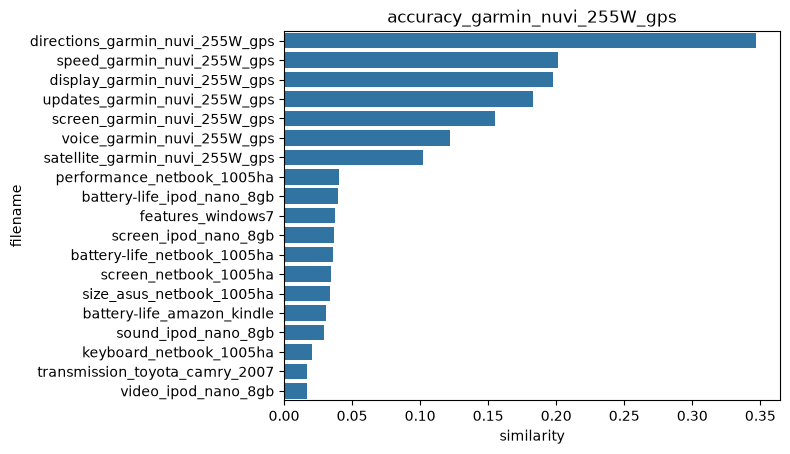

In [41]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sorted_index = similarity_pair.argsort()[:,::-1]
sorted_index = sorted_index[:, 1:]

hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]

hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value = hotel_1_sim_value[1:]

hotel_1_sim_df = pd.DataFrame()
hotel_1_sim_df['filename'] = document_df.iloc[hotel_sorted_indexes]['filename']
hotel_1_sim_df['similarity'] = hotel_1_sim_value
print('가장 유사도가 큰 파일명 및 유사도:\n', hotel_1_sim_df.iloc[0, :])

sns.barplot(x='similarity', y='filename', data=hotel_1_sim_df)
plt.title(comparison_docname)

In [44]:
import pandas as pd

train_df = pd.read_csv(r'C:\Users\USER\OneDrive\바탕 화면\과제 정리\공부용\Study-ML-DL-AI\allData\RatingsDataset\ratings_train.txt', sep='\t', encoding='utf-8')
train_df.head(3)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [45]:
train_df['label'].value_counts()

label
0    75173
1    74827
Name: count, dtype: int64

In [52]:
import re

train_df = train_df.fillna(' ')
train_df['document'] = train_df['document'].apply(lambda x : re.sub(r"\d+", " ", x))

test_df = pd.read_csv(r'C:\Users\USER\OneDrive\바탕 화면\과제 정리\공부용\Study-ML-DL-AI\allData\RatingsDataset\ratings_test.txt', sep='\t', encoding='utf-8')
test_df = test_df.fillna(' ')
test_df['document'] = test_df['document'].apply(lambda x : re.sub(r"\d+", " ", x))

# train_df.drop('id', axis=1, inplace=True)
test_df.drop('id', axis=1, inplace=True)

In [53]:
from konlpy.tag import Twitter

twitter = Twitter()

def tw_tokenizer(text):
  tokens_ko = twitter.morphs(text)
  return tokens_ko

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

tfidf_vect = TfidfVectorizer(tokenizer=tw_tokenizer, ngram_range=(1,2), min_df=3, max_df=0.9)
tfidf_vect.fit(train_df['document'])
tfidf_matrix_train = tfidf_vect.transform(train_df['document'])

lg_clf = LogisticRegression(random_state=0, solver='liblinear')

params = {'C': [1,3.5, 4.5, 5.5, 10]}
grid_cv = GridSearchCV(lg_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv.fit(tfidf_matrix_train, train_df['label'])
print(grid_cv.best_params_, round(grid_cv.best_score_,4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
{'C': 3.5} 0.8593


In [55]:
from sklearn.metrics import accuracy_score

tfidf_matrix_test = tfidf_vect.transform(test_df['document'])

best_estimator = grid_cv.best_estimator_
preds = best_estimator.predict(tfidf_matrix_test)

print('Logistic Regression 정확도: ', accuracy_score(test_df['label'], preds))

Logistic Regression 정확도:  0.86172


In [56]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

mercari_df=pd.read_csv(r'C:\Users\USER\OneDrive\바탕 화면\과제 정리\공부용\Study-ML-DL-AI\allData\MercariPriceSuggenstionChallenge\train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & Parts,Razer,52.0,0,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,"Adorable top with a hint of lace and a key hole in the back! The pale pink is a 1X, and I also have a 3X available in white!"


In [57]:
print(mercari_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  str    
 4   brand_name         849853 non-null   str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 90.5 MB
None


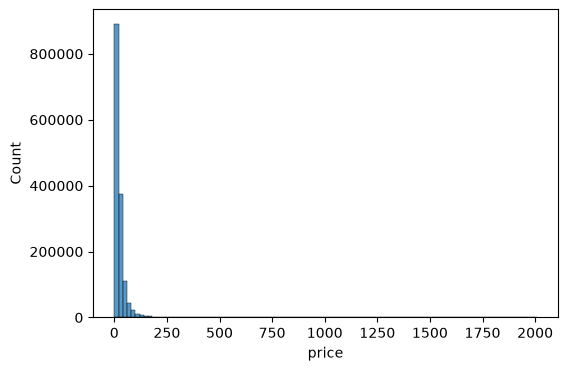

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

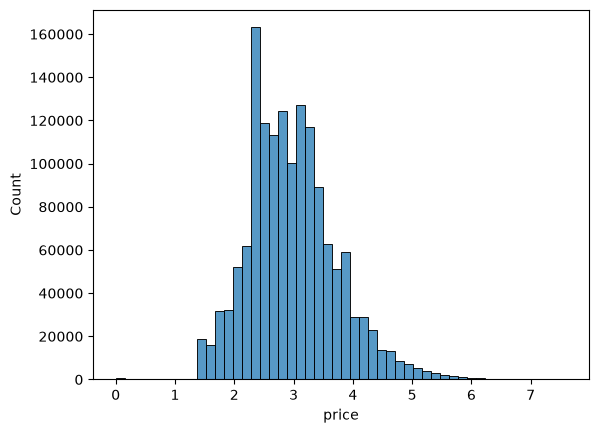

In [59]:
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

In [60]:
mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

0    2.397895
1    3.970292
2    2.397895
Name: price, dtype: float64

In [62]:
print('Shipping 값 유형:\n', mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n', mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


In [63]:
boolean_cond=mercari_df['item_description']=='No description yet'
mercari_df[boolean_cond]['item_description'].count()

np.int64(82489)

In [64]:
def split_cat(category_name):
  try:
    return category_name.split('/')
  except:
    return ['Other_Null', 'Other_Null', 'Other_Null']
  
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
zip(*mercari_df['category_name'].apply(lambda x: split_cat(x)))

print('대분류 유형: \n', mercari_df['cat_dae'].value_counts())
print('중분류 유형: \n', mercari_df['cat_jung'].value_counts())
print('소분류 유형: \n', mercari_df['cat_so'].value_counts())

대분류 유형: 
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 유형: 
 cat_jung
Athletic Apparel        134383
Makeup                  124624
Tops & Blouses          106960
Shoes                   100452
Jewelry                  61763
                         ...  
Candles                     64
Ceramics and Pottery        57
Dolls and Miniatures        49
Books and Zines             46
Quilts                      31
Name: count, Length: 114, dtype: int64
소분류 유형: 
 cat_so
Pants, Tights, Leggings    60177
Other                      50224
Face                       50171
T-Shirts                   46380
Shoes                      32168
            

In [65]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

mercari_df.isnull().sum()

train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
cat_dae              0
cat_jung             0
cat_so               0
dtype: int64

In [66]:
print('brand name의 유형 건수:', mercari_df['brand_name'].nunique())
print('brand name sample 5건: \n', mercari_df['brand_name'].value_counts()[:5])

brand name의 유형 건수: 4810
brand name sample 5건: 
 brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64


In [67]:
print('name의 종류 갯수: ',mercari_df['name'].nunique())
print('name sample 7건: \n', mercari_df['name'][:7])

name의 종류 갯수:  1225273
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: str


In [68]:
pd.set_option('max_colwidth', 200)

print('item_description 평균 문자열 크기:', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 크기: 145.71139703278507


0                                                                                                                                                                              No description yet
1    This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.
Name: item_description, dtype: str

In [70]:
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)

tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1,3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape:', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

name vectorization shape: (1482535, 105757)
item_description vectorization shape: (1482535, 50000)


In [71]:
from sklearn.preprocessing import LabelBinarizer

lb_brand_name=LabelBinarizer(sparse_output=True)
X_brand=lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id=LabelBinarizer(sparse_output=True)
X_item_cond_id=lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])
lb_shipping=LabelBinarizer(sparse_output=True)
X_shipping=lb_shipping.fit_transform(mercari_df['shipping'])

lb_cat_dae=LabelBinarizer(sparse_output=True)
X_cat_dae=lb_cat_dae.fit_transform(mercari_df['cat_dae'])
lb_cat_jung=LabelBinarizer(sparse_output=True)
X_cat_jung=lb_cat_jung.fit_transform(mercari_df['cat_jung'])
lb_cat_so=LabelBinarizer(sparse_output=True)
X_cat_so=lb_cat_so.fit_transform(mercari_df['cat_so'])

In [72]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print(f'X_brand shape:{X_brand.shape}, X_item_cond_id shape:{X_item_cond_id.shape}')
print(f'X_shipping shape:{X_shipping.shape}, X_cat_dae:{X_cat_dae.shape}')
print(f'X_cat_jung shape:{X_cat_jung.shape}, X_cat_so:{X_cat_so.shape}')

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape:(1482535, 4810), X_item_cond_id shape:(1482535, 5)
X_shipping shape:(1482535, 1), X_cat_dae:(1482535, 11)
X_cat_jung shape:(1482535, 114), X_cat_so:(1482535, 871)


In [73]:
from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

X_features_sparse = hstack(sparse_matrix_list).tocsc()
print(type(X_features_sparse), X_features_sparse.shape)

del X_features_sparse
gc.collect()

<class 'scipy.sparse._csc.csc_matrix'> (1482535, 161569)


3713

In [77]:
def rmsle(y, y_pred):
  return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):
  preds_exmpm = np.expm1(preds)
  y_test_exmpm = np.expm1(y_test)

  rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
  return rmsle_result

In [78]:
import gc
from scipy.sparse import hstack

def model_train_predict(model, matrix_list):
  X=hstack(matrix_list).tocsc()

  X_train, X_test, y_train, y_test = train_test_split(X, mercari_df['price'], test_size=0.2, random_state=156)

  model.fit(X_train, y_train)
  preds = model.predict(X_test)

  del X, X_train, X_test, y_train
  gc.collect()

  return preds, y_test

In [79]:
linear_model = Ridge(solver="lsqr", fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = (X_descp, X_name, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.4983853378155233
Item Description을 포함한 rmsle 값: 0.476623650707053


In [80]:
from lightgbm import LGBMRegressor

sparse_matrix_list=(X_descp, X_name, X_brand, X_item_cond_id,
                    X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
lgbm_preds, y_test = model_train_predict(model=lgbm_model, matrix_list=sparse_matrix_list)
print('LightGBM rmsle 값:', evaluate_org_price(y_test, lgbm_preds))

LightGBM rmsle 값: 0.4565536520931672


In [81]:
preds = lgbm_preds * 0.45 + linear_preds * 0.55
print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값:', evaluate_org_price(y_test, preds))

LightGBM과 Ridge를 ensemble한 최종 rmsle 값: 0.4497143130943587
